# From the CAPM to Multifactor Models

[From Mean-Variance to the CAPM](https://finm-32800.github.io/notebooks/_07_mean_variance_to_CAPM_ipynb.html)
got the CAPM from one-period mean-variance investors and market clearing.
This page drops the one-period assumption, and more than one factor
appears. It then covers two other routes to factor models, through
consumption and through arbitrage, and shows where Fama and French (1993)
fit. As before, it gives statements and intuition only, with links to the
papers that prove them.

The figures use Ken French's 25 size and book-to-market portfolios and his
three factors, monthly since 1965. The calculations are in
`src/calc_asset_pricing_theory.py`.

In [1]:
import calc_asset_pricing_theory
import figures
from settings import config

OUTPUT_DIR = config("OUTPUT_DIR")
tables = calc_asset_pricing_theory.load_tables(output_dir=OUTPUT_DIR)

## Step 1: Why one period is not enough

The investment opportunities investors face change over time: interest
rates move, expected returns rise and fall, and volatility comes and goes.
An investor with a long horizon cares about next period's wealth *and*
about what that wealth will be able to earn afterward.

A **state variable** is anything that moves those future opportunities. The
short rate, the market's expected return, and market volatility are the
usual examples.

## Step 2: The Intertemporal CAPM

**Statement ([Merton 1973](https://doi.org/10.2307/1913811)).** A
long-horizon investor holds the tangency portfolio plus one **hedging
portfolio** for each state variable, the portfolio that moves most closely
with changes in it. In equilibrium, expected excess returns depend on the
market beta and on one more beta per state variable:

$$
E[R_i] - r_f = \beta_{i,M}\,\lambda_M + \sum_{j=1}^{K} \beta_{i,j}\,\lambda_j ,
$$

where $\beta_{i,j}$ is asset $i$'s beta on hedging portfolio $j$ and
$\lambda_j$ is that portfolio's premium.

**Intuition.** An asset that pays off when opportunities get worse is
insurance. Investors want it, bid up its price, and accept a lower expected
return for it. An asset that does badly when opportunities get worse adds
risk on top of its market risk, so it has to pay a premium. Long-term bonds
are the textbook example: they gain when interest rates fall, which is
exactly when the return on future saving drops.

**The mean-variance version
([Fama 1996](https://doi.org/10.2307/2331355)).** In the CAPM, investors
hold a portfolio with the lowest variance for its expected return. In the
ICAPM, they hold a **multifactor efficient** portfolio: the lowest variance
for its expected return *and* its covariances with each state variable.
Market clearing works as it did last week, so the market is multifactor
efficient and the equation above follows. One period gave one factor. Many
periods give many factors.

## Step 3: The consumption CAPM

**Statement ([Breeden 1979](https://doi.org/10.1016/0304-405X(79)90016-3)).**
All of Merton's betas collapse into one, the beta with aggregate
consumption growth:

$$
E[R_i] - r_f \approx \gamma \, \mathrm{Cov}(R_i, \Delta c).
$$

**Intuition.** What investors ultimately care about is consumption. Bad news
about future opportunities matters only because it means less consumption
later. So an asset is risky exactly when it does badly at times when
consumption is low, when an extra dollar is worth the most. This is the most
general idea in asset pricing, and the market and the ICAPM's state
variables can be read as stand-ins for "bad times." The catch is
measurement: consumption is reported only quarterly and with error, and the
simple version of the model fits the data poorly.

## Step 4: The Arbitrage Pricing Theory, a different route

**Statement ([Ross 1976](https://doi.org/10.1016/0022-0531(76)90046-6)).**
Suppose returns have a factor structure,

$$
R_i = a_i + \sum_{k=1}^{K} b_{i,k} f_k + \varepsilon_i ,
$$

where the idiosyncratic parts $\varepsilon_i$ are unrelated across assets.
If there is no arbitrage, expected returns are approximately linear in the
factor loadings:

$$
E[R_i] - r_f \approx \sum_{k=1}^{K} b_{i,k}\,\lambda_k .
$$

**Intuition.** With many assets, a portfolio can diversify the
$\varepsilon_i$ away, leaving only its factor exposures. Two well-diversified
portfolios with the same exposures are then nearly the same asset, so they
must have nearly the same expected return. If they did not, you could buy
one and short the other for a profit with almost no risk. The APT needs no
assumption about investors' preferences and no market portfolio. The price
is that it says nothing about which factors matter or how large their
premiums should be.

## The four models side by side

| Model | Where the factors come from | Which factors |
|---|---|---|
| CAPM | One-period mean-variance investors and market clearing | The market only |
| ICAPM | Long-horizon investors hedging changes in their opportunities | The market plus one per state variable, not named by the theory |
| Consumption CAPM | Investors who care about consumption | Consumption growth |
| APT | A factor structure in returns and no arbitrage | Whatever drives the common movement in returns, not named by the theory |

## Step 5: From theory to Fama-French

The ICAPM and the APT say that extra factors can exist, but not what they
are. [Fama and French (1993)](https://doi.org/10.1016/0304-405X(93)90023-5)
went the other way and started from the data. Stocks sorted on size and
book-to-market leave large CAPM alphas, so they built two portfolios to
capture them: **SMB** (small minus big) and **HML** (high minus low
book-to-market).

The figure tests both models on the 25 size and book-to-market portfolios.
Each point is a portfolio. The horizontal axis is the average excess return
the model predicts from its betas, and the vertical axis is the average
excess return it actually earned. A model that prices the portfolios puts
every point on the 45-degree line.

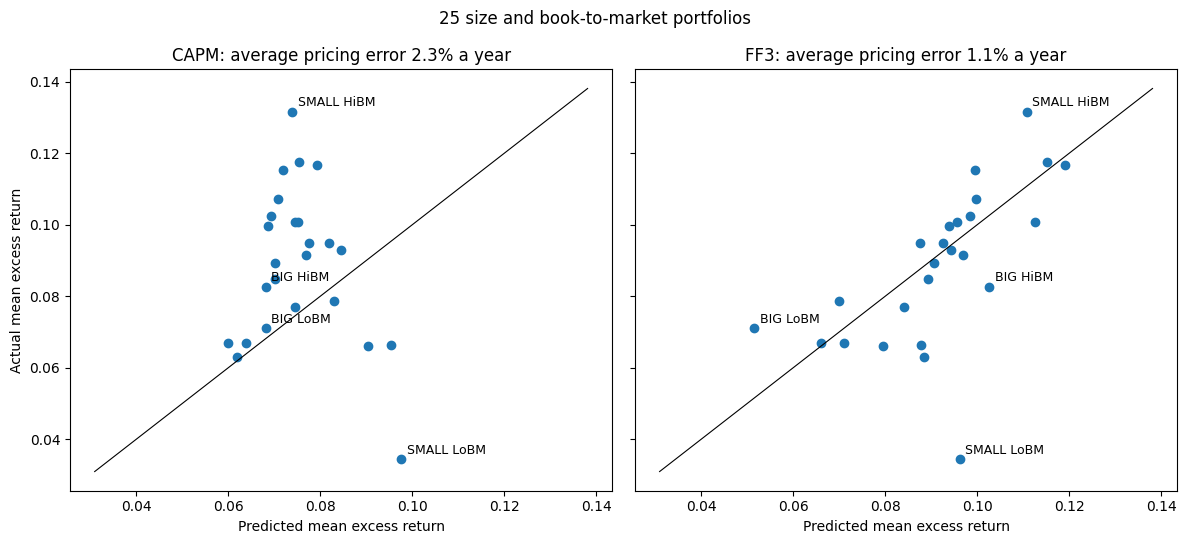

In [2]:
fig = figures.plot_predicted_vs_actual(tables["predicted_vs_actual"])

Under the CAPM, the portfolios have similar market betas, so the predicted
returns bunch together while the actual returns spread out: small value
stocks (SMALL HiBM) earn far more than predicted, and small growth stocks
(SMALL LoBM) far less. Adding SMB and HML spreads the predictions out and
pulls most points toward the line. Small growth stocks are still far below
it, which is the best-known failure of the three-factor model.

**Reading Fama-French as an ICAPM.**
[Fama and French (1996)](https://doi.org/10.1111/j.1540-6261.1996.tb05202.x)
and [Fama (1996)](https://doi.org/10.2307/2331355) interpret the
three-factor model as an ICAPM, with SMB and HML standing in for state
variables that investors want to hedge. It can also be read as an APT: SMB
and HML capture a large share of the common movement in stock returns.
Either way, this is an interpretation, not a derivation. No one has shown
which state variables SMB and HML track, and others argue the premiums come
from mispricing instead of risk
([Lakonishok, Shleifer, and Vishny 1994](https://doi.org/10.1111/j.1540-6261.1994.tb04772.x)).

The factors have earned their premiums on average, but not smoothly. The
figure shows the growth of \$1 in each one.

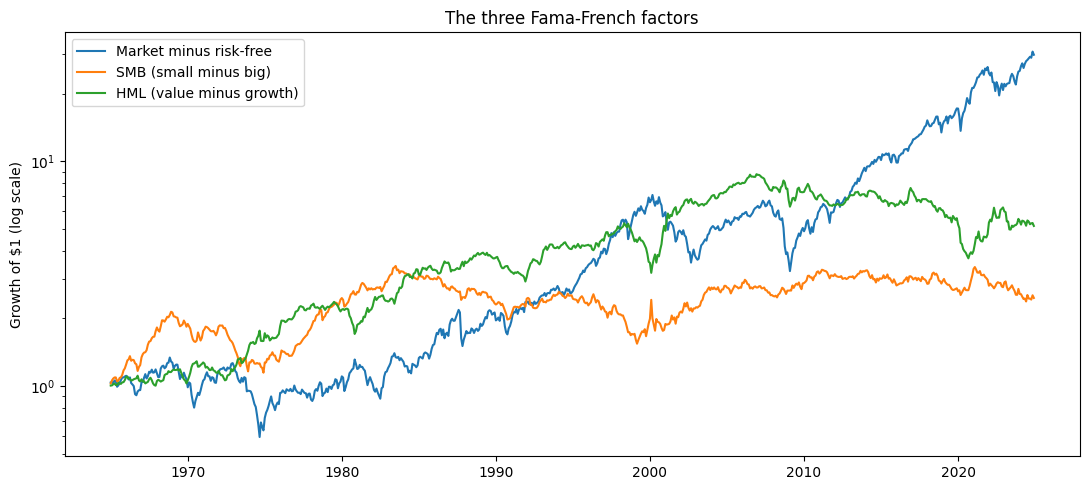

In [3]:
fig = figures.plot_factor_growth(tables["factor_growth"])

## Back to mean-variance

The story ends where it started. The CAPM says the market alone is the
tangency portfolio. A multifactor model says the tangency portfolio is a mix
of the factors, so Mkt, SMB, and HML together should reach a higher Sharpe
ratio than the market alone, and no other portfolio should have an alpha
once all three are in the regression.
[HW 1 Guide E](https://finm-32800.github.io/notebooks/_06_CAPM_and_Fama_French_ipynb.html)
tests both claims on the portfolios your HW 1 pipeline builds.

```{admonition} Discussion
:class: note
Are SMB and HML rewards for risk, or are they mispricing? What evidence
would tell the two apart?
```

Some answers that could come up:

- **Risk predicts bad times.** If the premiums compensate for risk, the
  factors should do badly in bad times, such as recessions or periods of
  low consumption, when investors can least afford losses.
- **Mispricing predicts corrections.** Lakonishok, Shleifer, and Vishny
  argue that investors extrapolate past growth and overprice growth stocks.
  Value stocks would then earn more as those expectations are corrected,
  for example around earnings announcements.
- **Publication should shrink mispricing.** Once a mispricing is published,
  traders can exploit it and it should fade. Returns on published
  predictors do fall after publication
  ([McLean and Pontiff 2016](https://doi.org/10.1111/jofi.12365)). HML's
  weak run since the late 2000s, visible in the figure above, is consistent
  with this, though it is also consistent with bad luck.
- **Data mining.** Hundreds of candidate factors have been proposed, and
  some will look priced by chance alone
  ([Harvey, Liu, and Zhu 2016](https://doi.org/10.1093/rfs/hhv059)).
- **Name the state variable.** The ICAPM reading is testable only if SMB and
  HML predict changes in investment opportunities, such as future market
  returns or economic growth.

## References

- Breeden, Douglas T. "An Intertemporal Asset Pricing Model with Stochastic
  Consumption and Investment Opportunities." *Journal of Financial
  Economics* 7, no. 3 (1979): 265-296.
- Fama, Eugene F. "Multifactor Portfolio Efficiency and Multifactor Asset
  Pricing." *Journal of Financial and Quantitative Analysis* 31, no. 4
  (1996): 441-465.
- Fama, Eugene F., and Kenneth R. French. "Common Risk Factors in the
  Returns on Stocks and Bonds." *Journal of Financial Economics* 33, no. 1
  (1993): 3-56.
- Fama, Eugene F., and Kenneth R. French. "Multifactor Explanations of Asset
  Pricing Anomalies." *Journal of Finance* 51, no. 1 (1996): 55-84.
- Harvey, Campbell R., Yan Liu, and Heqing Zhu. "... and the Cross-Section
  of Expected Returns." *Review of Financial Studies* 29, no. 1 (2016):
  5-68.
- Lakonishok, Josef, Andrei Shleifer, and Robert W. Vishny. "Contrarian
  Investment, Extrapolation, and Risk." *Journal of Finance* 49, no. 5
  (1994): 1541-1578.
- McLean, R. David, and Jeffrey Pontiff. "Does Academic Research Destroy
  Stock Return Predictability?" *Journal of Finance* 71, no. 1 (2016):
  5-32.
- Merton, Robert C. "An Intertemporal Capital Asset Pricing Model."
  *Econometrica* 41, no. 5 (1973): 867-887.
- Ross, Stephen A. "The Arbitrage Theory of Capital Asset Pricing." *Journal
  of Economic Theory* 13, no. 3 (1976): 341-360.